# Aperta walkthrough: walking accessibility in Central Paris

This notebook is a guided tour of every aperta primitive on a real-world
example: walking accessibility to supermarkets across Central Paris
(arrondissements 1–7 — the historic core of the city: Louvre, Bourse,
Marais, Latin Quarter, Saint-Germain, Invalides, ~14 km²). It takes
~1 minute on a laptop. All data is pulled from public sources
(OpenStreetMap via OSMnx; Uber's H3 grid system); no authentication or
external downloads beyond `pip install` are needed.

For a shorter introduction (~40 lines, ~10 s), see
[`minimal/accessibility.ipynb`](../minimal/accessibility.ipynb). For a
production-scale, multi-mode showcase, see [`extended/`](../extended/).

The notebook follows aperta's six-phase workflow:

1. **Load and prepare data** — OSM walking network, building footprints (as a
   synthetic population proxy), and supermarket POIs.
2. **Map data to units** — Uber H3 hex cells (resolution 10, ~66 m edge) and
   parent zones (resolution 8, ~460 m edge). H3's native parent-child
   relationship makes the cell→zone mapping deterministic and zero-cost.
3. **Build sparse OD pairs** — Three tiers based on zone-pair distance:
   `cells_to_cells` (close — both endpoints at cell precision),
   `cells_to_zones` (medium — cell origin, zone-aggregated dest),
   `zones_to_zones` (far — both endpoints at zone precision). The middle
   tier preserves per-cell origin precision in the regime where cell
   variation matters relative to trip cost.
4. *(skipped here)* Estimate traffic flows — not relevant for walking.
5. **Estimate travel costs** — Dijkstra shortest paths over the walking
   graph (scipy `csgraph.dijkstra`, FP32 by default).
6. **Calculate accessibilities** — Cumulative-opportunity, gravity, and
   nearest-*k* metrics.

The same code structure works for any city anywhere in the world — only the
area-of-interest string needs to change.

In [1]:
# `%matplotlib inline` makes figures show up inline below each cell when
# running in a Jupyter kernel; `autoreload` re-imports modules when their
# source changes on disk, so library edits don't require a kernel restart.
# All three are IPython magics — no-ops when running this file as plain Python.
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import warnings

import h3
import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon

import aperta.accessibility as accessibility
import aperta.geo_mapping as geo_mapping
import aperta.geo_processing as geo_processing
import aperta.network_processing as network_processing
import aperta.od_pairs as od_pairs
import aperta.overhead as overhead
import aperta.routing as routing
import aperta.utility as utility
import aperta.visualization as viz

warnings.filterwarnings('ignore', category=FutureWarning)

/opt/miniconda3/envs/aperta/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## 1. Area of interest

In [3]:
# OSMnx accepts a list of place names — the area-of-interest becomes the
# union of all listed polygons. For Central Paris we explicitly enumerate
# the seven historic arrondissements (the alternative `'Paris, France'`
# returns all 20, ~10× the network).
PLACE = [f'Paris {n} Arrondissement, France'
         for n in ('1er', '2e', '3e', '4e', '5e', '6e', '7e')]
LOCATION_LABEL = 'Central Paris (arrondissements 1–7)'
H3_RES_CELLS = 10  # ~66 m hex edge — building-block scale
H3_RES_ZONES = 8   # ~460 m hex edge — small-neighbourhood scale

# OSMnx returns the place polygon in WGS84 (EPSG:4326). When `PLACE` is a
# list, `geocode_to_gdf` returns one row per place — dissolve to a single
# union polygon so downstream code can treat the AOI uniformly.
boundary = ox.geocode_to_gdf(PLACE).dissolve()
boundary_proj_crs = boundary.estimate_utm_crs()  # local metric CRS

print(f"Place:          {LOCATION_LABEL}")
print(f"Projected CRS:  {boundary_proj_crs}")

Place:          Central Paris (arrondissements 1–7)
Projected CRS:  EPSG:32631


## 2. Build H3 hex grids: cells and zones

Uber's H3 is a hierarchical hex-grid system. Each H3 cell at resolution *N*
has a deterministic parent at resolution *N–1*, *N–2*, ... — no spatial join
needed for the cell→zone mapping.

In [4]:
boundary_geom = boundary.geometry.iloc[0]
cells = geo_processing.build_h3_grid(
    boundary_geom, H3_RES_CELLS,
    polygon_crs='EPSG:4326',
    target_crs=boundary_proj_crs,
)
# Each cell's parent at the zone resolution gives its zone assignment.
cells['zone_id'] = [h3.cell_to_parent(c, H3_RES_ZONES) for c in cells.index]

# Zones materialised from the unique zone parents.
zone_ids = sorted(cells['zone_id'].unique())
zones = gpd.GeoDataFrame(
    {'geometry': [Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(z)])
                  for z in zone_ids]},
    index=pd.Index(zone_ids, name='zone_id'),
    crs='EPSG:4326',
).to_crs(boundary_proj_crs)

print(f"{len(cells):,} cells in {len(zones):,} zones")

1,074 cells in 31 zones


## 3. Fetch OSM data

Three pulls: the walking network (for routing), building footprints (used as
a synthetic population proxy), and supermarket POIs (destinations).

A note on the network filter. The intuitive choice is `network_type='walk'`,
which excludes motorways and trunk roads. In practice this often produces
small disconnected pedestrian islands at city boundaries: pedestrian-only
paths (`highway=path`, `foot=designated`) that connect to the main grid
only via a trunk-tagged road get orphaned when that road is filtered out,
and OSMnx's default `retain_all=False` then drops them as non-largest
components. The cleaner choice for accessibility analyses in well-mapped
urban areas is `network_type='all'` — it keeps trunk roads (so the
pedestrian paths stay connected) at the cost of letting the router walk
along trunk roads in the (rare) cases where that's the shortest path.
For a careful production analysis you would either patch the graph
manually (re-add specific way IDs that bridge the gap) or use a custom
filter that respects `sidewalk=*` tags. We use `'all'` here as the
pragmatic compromise.

A second consideration is **directedness**. `graph_from_place` returns
a `MultiDiGraph` with directed edges that respect one-way tags — fine
for cars, but wrong for walking (pedestrians ignore one-ways). We
convert to undirected after projecting. Without this step, a small
number of cells whose snap-node sits on a one-way street's exit terminus
end up with almost no reachable destinations, producing zero
accessibility outliers that compress the colour scale on every map.

In [5]:
# Network. `graph_from_place` returns a MultiDiGraph clipped to the place
# polygon. See the note above on `network_type='all'` vs `'walk'`, and on
# the undirected conversion.
graph = ox.graph_from_place(PLACE, network_type='all', simplify=True)
graph = ox.project_graph(graph, to_crs=boundary_proj_crs)
# Pedestrians can walk either way on one-way streets; undirect after
# projecting (project_graph returns MultiDiGraph regardless of input).
graph = graph.to_undirected()
print(f"Network: {graph.number_of_nodes():,} nodes, {graph.number_of_edges():,} edges")

Network: 20,534 nodes, 33,214 edges


In [6]:
# Building footprints — synthetic population proxy.
# In a real analysis, replace this with gridded population (GHSL, WorldPop).
# Project to a metric CRS before computing centroids — centroid in geographic
# CRS is geometrically meaningless.
_b = ox.features_from_place(PLACE, tags={'building': True})
_b = _b[_b.geometry.type.isin(['Polygon', 'MultiPolygon'])][['geometry']].to_crs(boundary_proj_crs)
buildings = gpd.GeoDataFrame(
    geometry=_b.geometry.centroid.values,
    index=pd.Index(range(len(_b)), name='building_id'),
    crs=boundary_proj_crs,
)
print(f"{len(buildings):,} building footprints (centroids used as population pseudo-points)")

18,871 building footprints (centroids used as population pseudo-points)


In [7]:
# Supermarket POIs — destinations of interest for the accessibility analysis.
_s = ox.features_from_place(PLACE, tags={'shop': 'supermarket'}).to_crs(boundary_proj_crs)
supermarkets = gpd.GeoDataFrame(
    geometry=_s.geometry.centroid.values,
    index=pd.Index(range(len(_s)), name='supermarket_id'),
    crs=boundary_proj_crs,
)
print(f"{len(supermarkets):,} supermarkets")

66 supermarkets


A quick look at the inputs: the walking network (grey edges) and the
supermarket destinations (red), inside the AOI boundary.

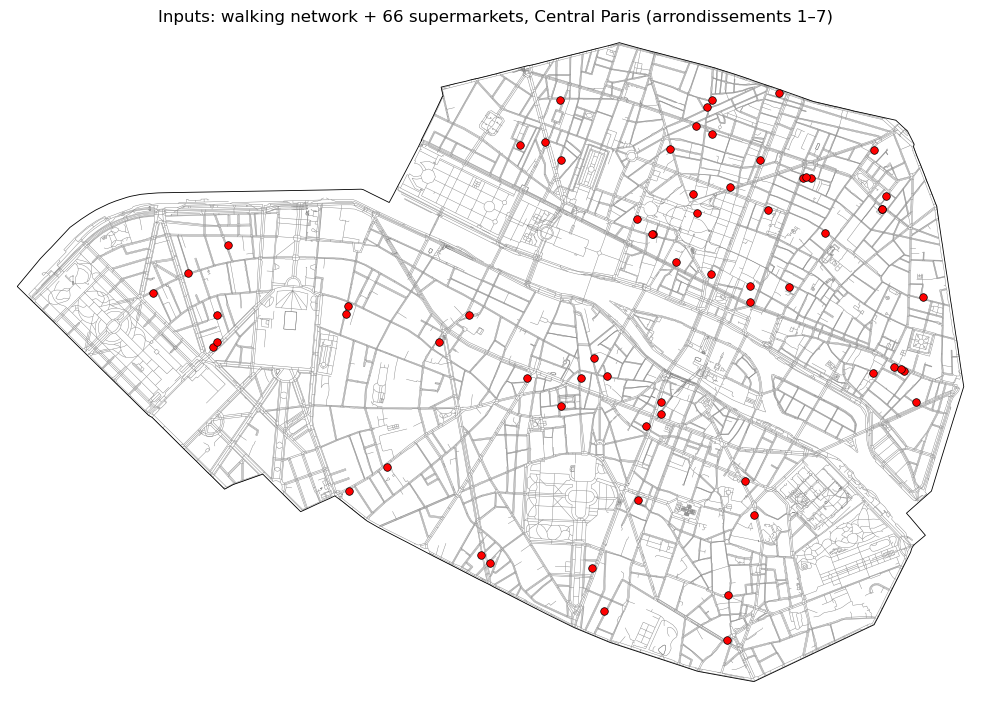

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))
ox.plot_graph(
    graph, ax=ax, node_size=0,
    edge_color='gray', edge_linewidth=0.3,
    bgcolor='white', show=False, close=False,
)
boundary.to_crs(boundary_proj_crs).boundary.plot(
    ax=ax, color='black', linewidth=0.6,
)
supermarkets.plot(
    ax=ax, color='red', markersize=30,
    edgecolor='black', linewidth=0.5, zorder=10,
)
ax.set_title(f'Inputs: walking network + {len(supermarkets)} supermarkets, {LOCATION_LABEL}')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 4. Map data to canonical units

Three mappings: cells (and zones) get nearest network nodes; buildings and
supermarkets get assigned to the cell whose polygon contains them.

In [9]:
# Walking speed in m/s (OSMnx default; used both for edge routing and for the
# cell→node walking-overhead estimate below).
WALK_SPEED_MS = 1.4

# Snap each cell's centroid to its nearest network node. `snap_to_network_nodes`
# returns both the node ID and the Euclidean distance from the cell centroid to
# that node — exactly what we need for the per-cell trip-overhead estimate.
cell_centroids_gdf = gpd.GeoDataFrame(
    geometry=cells.geometry.centroid, index=cells.index, crs=cells.crs,
)
cells['node_id'], dist_to_node = network_processing.snap_to_network_nodes(
    cell_centroids_gdf, graph,
)
# Walking overhead is the centroid→node distance divided by walking speed.
# Aperta's accessibility cell-mode adds this to every destination cost so that
# two cells sharing the same network node still report different accessibilities.
cells['walk_overhead_s'] = dist_to_node / WALK_SPEED_MS

**Zone snapping via tiered transport centroid.** Naively snapping each zone's
*geometric* centroid to the nearest node often lands on something arbitrary —
a service road behind a building, a cul-de-sac, or (with `network_type='all'`)
even a motorway on-ramp. For zones at ~460 m H3 hex resolution covering
heterogeneous urban geometry, this matters: the zone-representative node
anchors all zone-tier OD-routing AND the routing-based destination-overhead
calculations.

The cleaner approach: classify nodes by the highest tier of road that
touches them, exclude the top tier (motorways / trunk roads) and the bottom
tier (pedestrian-only paths), then snap each zone to the eligible node
nearest to the *median* coordinates of the zone's eligible interior nodes —
the zone's transport-weighted centroid. This is what
`assign_to_eligible_centroid` does.

In [10]:
# Map OSM highway tags to an ordinal road class (1 = pedestrian-only / off-road
# trails, 5 = primary / trunk). Used both for the tier-aware zone snap below
# and the path-first per-edge feature aggregation in §10.
HIGHWAY_CLASS_MAP = {
    'footway': 1, 'pedestrian': 1, 'path': 1, 'steps': 1, 'track': 1,
    'living_street': 2, 'residential': 2,
    'service': 3, 'unclassified': 3, 'tertiary': 3, 'tertiary_link': 3,
    'secondary': 4, 'secondary_link': 4,
    'primary': 5, 'primary_link': 5, 'trunk': 5, 'trunk_link': 5,
    'motorway': 5, 'motorway_link': 5,
}


def edge_road_class(u, v, data) -> float:
    """Per-edge road class. OSMnx stores `highway` as a string or list (for
    edges tagged with multiple types); pick the first and look it up,
    defaulting to 3 (mid-range) for tags we don't know."""
    h = data.get('highway')
    if isinstance(h, list):
        h = h[0] if h else None
    return float(HIGHWAY_CLASS_MAP.get(h, 3))


# Per-node tier = max road class among the node's connected edges.
node_road_class = network_processing.aggregate_edges_to_nodes(
    graph, edge_attribute=edge_road_class, aggregator='max',
)
# Eligible zone-snap targets: nodes whose highest-class touching road is
# residential through secondary (tiers 2–4). Excludes pure-pedestrian-path-only
# nodes (tier 1) — too minor to anchor a zone — and motorway / trunk nodes
# (tier 5) — pedestrians don't realistically arrive at those.
eligible_zone_nodes = node_road_class[
    (node_road_class >= 2) & (node_road_class <= 4)
].index
print(f"{len(eligible_zone_nodes):,} / {graph.number_of_nodes():,} graph nodes "
      f"are eligible as zone-snap targets (tier 2–4).")

# Snap each zone via the median of its eligible interior nodes (transport
# centroid), falling back to the geometric centroid for any zone with no
# eligible node inside.
zones['node_id'], _ = network_processing.assign_to_eligible_centroid(
    zones, graph, eligible_node_ids=eligible_zone_nodes,
)

7,738 / 20,534 graph nodes are eligible as zone-snap targets (tier 2–4).


In [11]:
# Assign each building to the cell whose polygon contains its centroid.
# `allow_nearest=True` catches the rare case of a centroid landing just
# outside the H3 hex coverage; the distance return is unused here.
buildings['cell_id'], _ = geo_mapping.map_points_to_polygons(
    buildings, cells, allow_nearest=True,
)
pop_by_cell = buildings.groupby('cell_id').size()
cells['population'] = pop_by_cell.reindex(cells.index, fill_value=0).astype(float)

In [12]:
# Same for supermarkets.
supermarkets['cell_id'], _ = geo_mapping.map_points_to_polygons(
    supermarkets, cells, allow_nearest=True,
)
sm_by_cell = supermarkets.groupby('cell_id').size()
cells['supermarkets'] = sm_by_cell.reindex(cells.index, fill_value=0).astype(float)

In [13]:
# Aggregate destination weights up to the zone level so the zone tier carries
# the right per-zone totals (one row per zone, summing cells below it).
zones['population'] = cells.groupby('zone_id')['population'].sum().reindex(
    zones.index, fill_value=0).astype(float)
zones['supermarkets'] = cells.groupby('zone_id')['supermarkets'].sum().reindex(
    zones.index, fill_value=0).astype(float)

print(f"Total pseudo-population: {cells['population'].sum():,.0f} buildings")
print(f"Cells with at least one supermarket: {(cells['supermarkets'] > 0).sum()}")

Total pseudo-population: 18,871 buildings
Cells with at least one supermarket: 59


## 5. Build tiered origin-destination pairs

Three radii classify every zone-pair into one of three tiers:

- `cells_to_cells` (`d(Z, Z') < r_cells`): cell origin and cell dest —
  highest precision, kept small to bound storage.
- `cells_to_zones` (`r_cells ≤ d < r_medium`): cell origin, zone-
  aggregated dest — preserves per-cell origin precision in the regime
  where the per-cell dest precision starts being washed out by the
  trip cost.
- `zones_to_zones` (`r_medium ≤ d < r_zones`): zone-aggregated both
  sides — cheapest tier, used for far destinations where neither
  endpoint's individual cell identity matters much.

`r_medium` defaults to `min(r_cells * 10, r_zones)` if not given —
we pass it explicitly here so all three tiers are visible.

In [14]:
R_CELLS  = 1_500.0   # 1.5 km — cells_to_cells (within ~20 min walking)
R_MEDIUM = 3_000.0   # 3 km   — cells_to_zones middle tier
R_ZONES  = 8_000.0   # 8 km   — zones_to_zones outer cutoff

pairs = od_pairs.get_pairs(
    cells, r_cells=R_CELLS, node_column='node_id',
    zones=zones, r_zones=R_ZONES, r_medium=R_MEDIUM,
)
print(pairs)

TieredODNodePairs(cells_to_cells: 1,074 orig → 325,128 dest; cells_to_zones: 1,074 orig → 15,652 dest; zones_to_zones: 31 orig → 328 dest)


Visualising the tiered structure from one origin. `plot_tiered_destinations`
draws each tier's destinations in a distinct colour:

- **Red** — origin cell
- **Gold** — `cells_to_cells` destinations (cell precision)
- **Teal** — `cells_to_zones` destinations (zone-aggregated, mid-distance)
- **Blue** — `zones_to_zones` destinations (zone-aggregated, far)

The three layers fan out concentrically: the per-cell tier is the
small high-resolution core, the middle tier is the surrounding annulus
of zone-aggregated dests, the far tier is the outer ring (often
overlapping the middle tier in the visualisation since the same
destination zone may show up at different tiers from different
origins). High resolution where it matters, coarser resolution where it
doesn't.

In [15]:
# Pick an origin cell near the centre of the AOI for the illustration.
_center = boundary.to_crs(boundary_proj_crs).geometry.iloc[0].centroid
demo_cell_id = cells.geometry.centroid.distance(_center).idxmin()

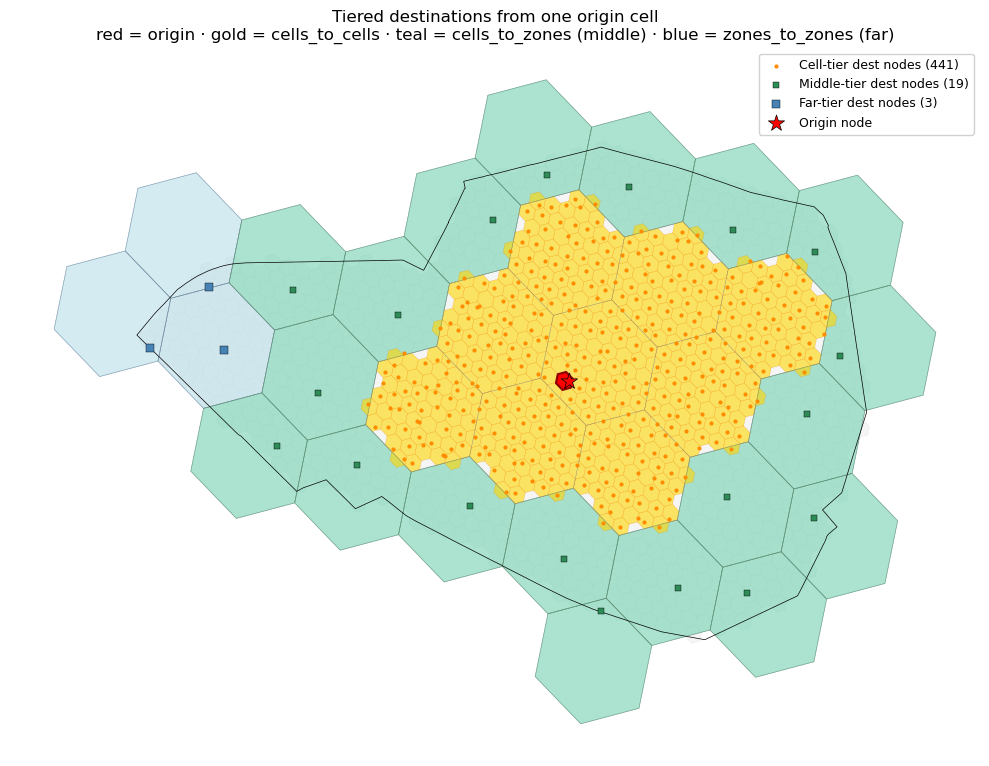

In [16]:
viz.plot_tiered_destinations(
    cells, zones, pairs,
    origin_cell_id=demo_cell_id,
    graph=graph,
    boundary=boundary.to_crs(boundary_proj_crs),
    title=('Tiered destinations from one origin cell\n'
           'red = origin · gold = cells_to_cells · '
           'teal = cells_to_zones (middle) · '
           'blue = zones_to_zones (far)'),
)
plt.tight_layout()
plt.show()

## 6. Compute travel times (Dijkstra over the walking graph)

`tiered_path_costs` routes every OD pair in `pairs` via
`scipy.sparse.csgraph.dijkstra` (one single-source call per origin)
and returns a `TieredODNodePairs` of cost arrays — same shape as
`pairs`, position-aligned with the per-origin dest arrays.

`cutoff=T` (optional) caps each per-origin search at `T` weight-units
(seconds here, since edge weight is travel time). Worth using when
the graph is much larger than the longest realistic trip: scipy's
`limit=` parameter truncates the Dijkstra frontier once it exceeds T,
which can be a big speed-up on country-scale networks. At Central
Paris scale (graph diameter ≈ 30 min walking) the cutoff barely
matters, but we set it for illustration.

Output dtype is `np.float32` by default (halves storage versus FP64
with no meaningful precision loss for travel costs in seconds). Pass
`dtype=np.float64` if downstream arithmetic needs the extra range.

In [17]:
# Convert each edge's length (m) into a walking time (s).
for u, v, k, data in graph.edges(keys=True, data=True):
    data['walk_time_s'] = data['length'] / WALK_SPEED_MS

times = routing.tiered_path_costs(
    pairs, graph, weight='walk_time_s',
    cutoff=45 * 60,  # 45 min upper bound; r_zones * (1/walk_speed) gives ≈30 min
)
print(times)

TieredODNodePairs(cells_to_cells: 1,074 orig → 325,128 dest; cells_to_zones: 1,074 orig → 15,652 dest; zones_to_zones: 31 orig → 328 dest)


## 7. Lift to geo-keyed form, bake per-cell overhead, build weights

Routing produces a *node-keyed* `TieredODNodePairs` — keys are network node
IDs. To get **per-cell** accessibility output, baked **per-cell origin
overhead**, or cross-modal aggregation across different graphs, lift to
`TieredODGeoPairs` (keys = cell IDs / zone IDs).

Three steps:

1. `reindex_by_geo_unit` — fan out node-keyed entries to cell/zone entries.
2. `add_origin_cell_overhead` — bake per-cell first-mile into the cost ODM
   (per-cell at `cells_to_cells` + `cells_to_zones`, per-zone-mean at
   `zones_to_zones` since the far tier is keyed by zone, not cell).
3. `dest_values_geo` — build per-cell destination weight ODMs directly.

In [18]:
pairs_geo, times_geo = od_pairs.reindex_by_geo_unit(
    pairs, times, cells,
    cell_node_column='node_id',
    zones=zones, zone_node_column='node_id',
)
times_geo = overhead.add_origin_cell_overhead(
    times_geo, pairs_geo, cells, 'walk_overhead_s',
)
sm_weights = od_pairs.dest_values_geo(
    'supermarkets', pairs_geo, cells, zones=zones,
)
# Cell → zone lookup for tier stitching in the accessibility metrics.
cell_to_zone = cells['zone_id'].to_dict()

print(times_geo)

TieredODGeoPairs(cells_to_cells: 1,074 orig → 325,128 dest; cells_to_zones: 1,074 orig → 15,652 dest; zones_to_zones: 31 orig → 328 dest)


## 8. Accessibility metrics

Three flavours, computed against the geo-keyed cost ODM with overhead baked
in. Output is indexed by cell ID — ready to join back to the cells
GeoDataFrame for mapping. No per-call `cells=` / `node_column=` /
`cell_overhead_column=` kwargs needed — the geo-keyed input does the work.

### Cumulative-opportunity: supermarkets reachable per time band

In [19]:
bins = [
    accessibility.Bin('0_to_5min',   0,           5 * 60),
    accessibility.Bin('5_to_15min',  5 * 60,     15 * 60),
    accessibility.Bin('15_to_30min', 15 * 60,    30 * 60),
]
acc_cum = accessibility.cumulative_opportunities(
    times_geo, {'supermarkets': sm_weights}, cell_to_zone, bins,
)

# Cumulative variant — supermarkets reachable WITHIN X minutes.
acc_within = pd.DataFrame({
    'within_5min':  acc_cum[('0_to_5min', 'supermarkets')],
    'within_15min': (acc_cum[('0_to_5min', 'supermarkets')]
                     + acc_cum[('5_to_15min', 'supermarkets')]),
    'within_30min': (acc_cum[('0_to_5min', 'supermarkets')]
                     + acc_cum[('5_to_15min', 'supermarkets')]
                     + acc_cum[('15_to_30min', 'supermarkets')]),
})
acc_within.head()

,within_5min,within_15min,within_30min
cell,,,
8a1fb4644c37fff,0.0,0.0,26.0
8a1fb4644cb7fff,0.0,2.0,18.0
8a1fb4644d07fff,0.0,5.0,35.0
8a1fb4644d17fff,0.0,3.0,28.0
8a1fb4644d1ffff,0.0,1.0,23.0


### Gravity: exponential decay, three β values in one call

The cost ODM is floored at 30 s via `floor_intrazonal_costs` before passing
to gravity. Without that floor, the intrazonal self-pair would route at
cost 0, sending `exp(-β · 0) = 1` to maximum decay weight (giving a cell's
own supermarkets infinite advantage over neighbours).

In [20]:
times_geo_floored = routing.floor_intrazonal_costs(times_geo, min_cost=30.0)

decays = [
    accessibility.exp_decay('beta_005', 0.005),  # half-decay ~140 s ≈ 2 min
    accessibility.exp_decay('beta_002', 0.002),  # half-decay ~350 s ≈ 6 min
    accessibility.exp_decay('beta_001', 0.001),  # half-decay ~700 s ≈ 12 min
]
acc_gravity = accessibility.gravity(
    times_geo_floored, {'supermarkets': sm_weights}, cell_to_zone, decays,
)
acc_gravity.head()

decay,beta_005,beta_002,beta_001
property,supermarkets,supermarkets,supermarkets
cell,,,
8a1fb4644c37fff,0.062596,2.263402,10.158947
8a1fb4644cb7fff,0.057553,1.906056,9.145014
8a1fb4644d07fff,0.190539,3.172808,11.763071
8a1fb4644d17fff,0.122852,3.022046,11.703640
8a1fb4644d1ffff,0.068621,2.417983,10.537216


### Nearest-*k*: mean walking time to the *k* nearest supermarkets

Default aggregator is `'cost_mean'` — the mean cost over the *k* nearest
weight-units (each supermarket counts as one opportunity at its
destination's cost). **Lower values = better accessibility**, and `k = 3`
and `k = 5` are directly comparable on the same (seconds) scale. Cells with
fewer than *k* reachable supermarkets show `NaN`.

In [21]:
acc_nk = accessibility.nearest_k(
    times_geo, {'supermarkets': sm_weights}, cell_to_zone, ks=[1, 3, 5],
)
acc_nk.head()

k,1,3,5
property,supermarkets,supermarkets,supermarkets
cell,,,
8a1fb4644c37fff,903.913147,928.268066,965.768250
8a1fb4644cb7fff,829.353699,870.396667,980.908020
8a1fb4644d07fff,605.854004,686.646423,704.528442
8a1fb4644d17fff,725.996521,802.627136,867.709778
8a1fb4644d1ffff,858.657593,930.931580,979.907410


## 9. Visualise

Three choropleths, one per metric family. Cells with their accessibility
value as fill colour; supermarket locations overlaid.

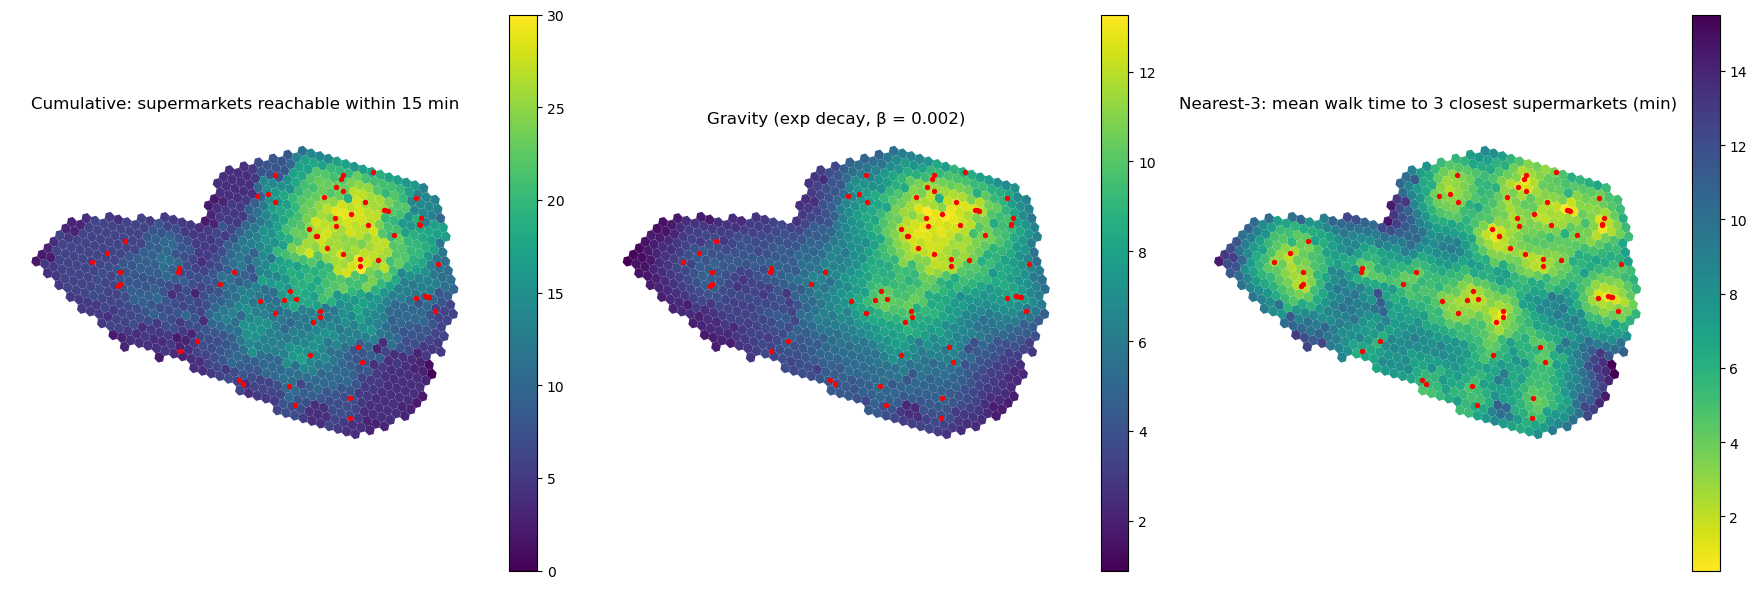

In [22]:
# Three panels, three metrics. The first two are "bigger = better"; the
# third (nearest-3 cost in minutes) is "smaller = better", so we use a
# reversed colormap to keep the visual convention "bright = good" consistent.
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sm_overlay = [(supermarkets, {'color': 'red', 'markersize': 8})]
viz.plot_cell_values(
    cells, acc_within['within_15min'], ax=axes[0],
    title='Cumulative: supermarkets reachable within 15 min',
    overlays=sm_overlay,
)
viz.plot_cell_values(
    cells, acc_gravity[('beta_002', 'supermarkets')], ax=axes[1],
    title='Gravity (exp decay, β = 0.002)',
    overlays=sm_overlay,
)
viz.plot_cell_values(
    cells, acc_nk[(3, 'supermarkets')] / 60, ax=axes[2],
    title='Nearest-3: mean walk time to 3 closest supermarkets (min)',
    cmap='viridis_r',
    overlays=sm_overlay,
)
plt.tight_layout()
plt.show()

## 10. Adding a bike mode (separate network + intersection-aware edge times)

Cycling-walking is the canonical "soft modes" pair for accessibility
analyses in dense European city centres — cycling-infrastructure
expansion in central Paris (Plan Vélo, cyclable arteries, low-traffic
neighbourhoods) is one of the most actively-studied urban-planning
topics right now. Compared to walking, biking is ~3× faster but has
setup overhead (unlock, parking) and pays a time penalty at every
intersection traversed.

This section adds the bike mode end-to-end in the **time domain** —
fetch network, intersection-aware edge times, overhead, route, lift
to geo-keyed form, bake overhead. A per-edge bike-friendliness score
(used as a route-feature in the utility section later) is computed
in §11. The walk + bike utilities + cross-modal logsum follow in §13.

Two new ingredients beyond the walking template:

1. **Edge weights richer than baseline length / speed.** Each
   bike-network edge gets a per-traversal time penalty added to its
   `length / bike_speed` baseline — every intersection crossed costs
   a few seconds of stop-and-go. The router uses these
   penalty-augmented weights, so a slightly-longer detour that avoids
   one extra intersection can win on total time.
2. **An overhead the walking mode doesn't have.** Unlocking the bike
   + walking to it adds ~30–60 s of trip-invariant cost. For very
   short trips this can flip the fastest-mode choice back to walking
   — exactly the cross-modal effect demonstrated in §12.

### 10.1 Fetch and snap the bike network

Same `.to_undirected()` step we used for the walking graph: OSMnx
returns a `MultiDiGraph` that respects OSM `oneway=*` tags, which would
otherwise leave a handful of cells whose snap-node sits at a one-way
exit terminus with almost no reachable destinations.

**Jurisdiction caveat:** undirecting assumes bikes can ride against
any one-way street. That holds in Paris, Brussels, Amsterdam etc.
(general contraflow cycling allowance) but is too permissive for
strict jurisdictions (much of the US, parts of Germany). For a
production analysis the cleaner pattern is to keep the graph directed
AND re-snap cells away from problem nodes by restricting snap targets
to the largest strongly-connected component:

```python
import networkx as nx
main_scc = max(nx.strongly_connected_components(bike_graph), key=len)
cells['bike_node_id'], _ = network_processing.assign_to_eligible_centroid(
    cells, bike_graph, eligible_node_ids=main_scc,
)
```

Or use OSM tags (`oneway:bicycle=no`, `cycleway:left=opposite_lane`,
`bicycle:backward=yes`) to pre-filter edges so the bike-graph is
directed-but-jurisdiction-correct. Both options are out of scope here.

In [23]:
bike_graph = ox.graph_from_place(PLACE, network_type='bike', simplify=True)
bike_graph = ox.project_graph(bike_graph, to_crs=boundary_proj_crs)
bike_graph = bike_graph.to_undirected()   # bikes assumed to ignore one-ways
print(f"Bike network: {bike_graph.number_of_nodes():,} nodes, "
      f"{bike_graph.number_of_edges():,} edges")

# Per-cell snapping (centroid → nearest bike-network node), capturing the
# centroid→node distance for the per-cell first-mile overhead below.
cells['bike_node_id'], bike_dist_to_node = network_processing.snap_to_network_nodes(
    cell_centroids_gdf, bike_graph,
)

# Zone snapping via transport centroid (same tier-aware logic as for walk).
bike_node_road_class = network_processing.aggregate_edges_to_nodes(
    bike_graph, edge_attribute=edge_road_class, aggregator='max',
)
bike_eligible_nodes = bike_node_road_class[
    (bike_node_road_class >= 2) & (bike_node_road_class <= 4)
].index
zones['bike_node_id'], _ = network_processing.assign_to_eligible_centroid(
    zones, bike_graph, eligible_node_ids=bike_eligible_nodes,
)

Bike network: 3,510 nodes, 5,480 edges


### 10.2 Intersection-aware edge times

Each edge's bike-time is its `length / bike_speed` baseline plus a flat
per-edge penalty — in a simplified OSMnx graph (every degree-2 node
collapsed away), each edge spans exactly one intersection-to-intersection
segment, so charging the penalty per edge directly counts intersections
along the route. Two effects worth predicting:

- The router prefers paths with fewer edges, all else equal.
- Routes via longer arterial segments (fewer intersections) get
  cheaper than dense grid-routes with many short turns.

This is a deliberately tiny example of "edge weights richer than
pure length / speed". For systematic calibration against observed
travel times see the separate `calibrate_edge_weights.ipynb` notebook.

In [24]:
BIKE_SPEED_MS = 20 / 3.6           # 20 km/h, typical urban cycling speed
INTERSECTION_PENALTY_S = 8.0       # stop-and-go time per intersection traversed

for u, v, k, data in bike_graph.edges(keys=True, data=True):
    base_time = float(data['length']) / BIKE_SPEED_MS
    data['bike_time_s'] = base_time + INTERSECTION_PENALTY_S

### 10.3 Bike overhead (unlock + walk-to-bike)

Per-cell origin overhead = walk-to-bike + fixed setup time. No
density-dependent term (unlike cars, bikes don't need to "find
parking" at scale in central Paris).

In [25]:
BIKE_INIT_SPEED_MS = 1.4       # walk-to-bike speed
BIKE_SETUP_S = 30.0            # unlock + helmet

cells['bike_overhead_s'] = bike_dist_to_node / BIKE_INIT_SPEED_MS + BIKE_SETUP_S
print(f"Bike overhead per cell: mean {cells['bike_overhead_s'].mean():.1f}s, "
      f"5-95 pct [{cells['bike_overhead_s'].quantile(0.05):.1f}, "
      f"{cells['bike_overhead_s'].quantile(0.95):.1f}]")

Bike overhead per cell: mean 61.8s, 5-95 pct [36.2, 104.8]


### 10.4 Route, lift to geo, bake overhead

Same three-step pattern as the walking pipeline (§6, §7): route on the
bike graph → reindex to geo-keyed form → bake per-cell origin overhead
into the cost ODM. The result `bike_times_geo` is a `TieredODGeoPairs`
of bike travel times in seconds with overhead included, ready to combine
with `times_geo` in the cross-modal section that follows.

In [26]:
bike_pairs = od_pairs.get_pairs(
    cells, r_cells=R_CELLS, node_column='bike_node_id',
    zones=zones, r_zones=R_ZONES, r_medium=R_MEDIUM,
)
# Note: `r_medium` is passed explicitly so the bike ODM has the SAME
# three-tier structure as the walk ODM. `aggregate_across_modes` (below)
# requires consistent tier structure across modes — without an explicit
# `r_medium`, the bike call would auto-infer `r_medium = min(r_cells * 10,
# r_zones) = r_zones`, collapsing the far tier and crashing the cross-modal
# call.
bike_times = routing.tiered_path_costs(bike_pairs, bike_graph, weight='bike_time_s')
bike_pairs_geo, bike_times_geo = od_pairs.reindex_by_geo_unit(
    bike_pairs, bike_times, cells,
    cell_node_column='bike_node_id',
    zones=zones, zone_node_column='bike_node_id',
)
bike_times_geo = overhead.add_origin_cell_overhead(
    bike_times_geo, bike_pairs_geo, cells, 'bike_overhead_s',
)
print(bike_times_geo)

TieredODGeoPairs(cells_to_cells: 1,074 orig → 332,778 dest; cells_to_zones: 1,074 orig → 15,836 dest; zones_to_zones: 31 orig → 328 dest)


## 11. Path-first: per-edge feature aggregation along realised routes

Everything above used aperta's *cost* primitive — routing returns one
scalar (travel time) per OD pair, and the accessibility metrics aggregate
those scalars. But aperta is also **path-first**:
`routing.tiered_path_aggregate` routes shortest paths and aggregates any
per-edge attribute along each realised path, returning per-OD-pair
scalars. Memory cost is the same as `tiered_path_costs` (paths are
processed per-origin and discarded after aggregation).

Concrete use case on the bike network we just built: a **bike-friendliness
score** along each shortest cycling route. We tag each edge 1 (busy
primary road) to 5 (dedicated cycleway), combining road tier and OSM
cycleway-infrastructure tags. Aggregated by mean along the route, this
answers "from this cell, how bike-friendly are the typical routes I'd
ride?" — a route-quality metric the cost-only metrics in §8/§9 cannot
express, because they see only OD time, not route geometry.

Same primitive applies to any per-edge feature: gradient, surface type,
perceived safety, pollution exposure, lit-vs-unlit. Whatever you can
attach to an edge, you can aggregate along realised routes. The bike
score plays a second role in §13: it enters the bike utility as a
`RouteFeature`, so cyclists value bike-friendly routes proportionally
in the discrete-choice accessibility metric.

In [27]:
def edge_bike_score(u, v, data) -> float:
    """Per-edge bike-friendliness, 1 (worst) to 5 (best for cycling).

    Combines road tier (quieter = better) with OSM bicycle-infrastructure
    tags. Dedicated cycleways score 5 outright; otherwise the base score
    comes from road tier (inverse of `edge_road_class`: pedestrian = 5,
    residential = 4, ..., primary/motorway = 1), with a +1 / +2 bonus
    for cycleway lane / track on the road, capped at 5.
    """
    h = data.get('highway')
    if isinstance(h, list):
        h = h[0] if h else None
    # Dedicated bike infrastructure wins outright.
    if h == 'cycleway' or data.get('bicycle') == 'designated':
        return 5.0
    # Base score = inverse of road tier (1..5 → 5..1).
    base = 6 - int(edge_road_class(u, v, data))
    # Bonus for any cycleway infrastructure tagged on this road.
    cw = (data.get('cycleway')
          or data.get('cycleway:left')
          or data.get('cycleway:right'))
    if isinstance(cw, list):
        cw = cw[0] if cw else None
    if cw in ('track', 'opposite_track'):
        bonus = 2
    elif cw:                  # 'lane', 'shared', 'opposite_lane', etc.
        bonus = 1
    else:
        bonus = 0
    return float(min(5, base + bonus))


# `PathAggregation` matches the `Bin` / `Decay` namedtuple style used
# elsewhere in aperta: a named spec consisting of an attribute extractor
# and an aggregator. `tiered_path_aggregate` returns both the per-pair
# costs and the per-pair aggregated features — same single routing pass.
_costs, path_aggs = routing.tiered_path_aggregate(
    bike_pairs, bike_graph, weight='bike_time_s',
    edge_aggregations=[
        routing.PathAggregation('bike_score_avg', edge_bike_score, 'mean'),
    ],
)
bike_score_odm = path_aggs['bike_score_avg']
print(bike_score_odm)

TieredODNodePairs(cells_to_cells: 1,001 orig → 285,365 dest; cells_to_zones: 1,001 orig → 14,615 dest; zones_to_zones: 31 orig → 328 dest)


Visualise per origin: unweighted mean across cell-tier destinations.
(For a more focused metric, you could weight by `supermarkets` and only
consider routes to supermarket cells; left as an exercise.)

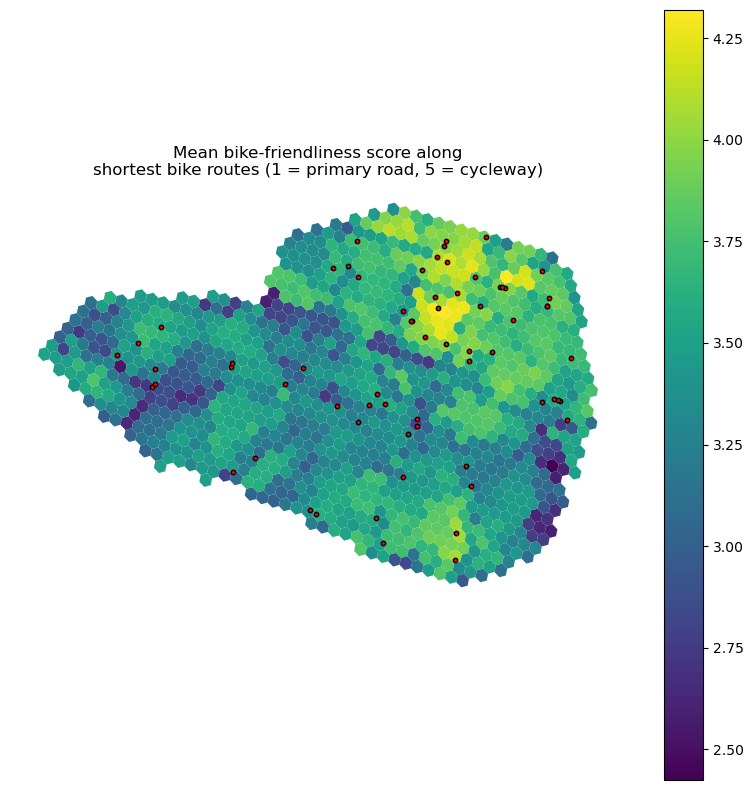

In [28]:
per_origin_bike_score = pd.Series(
    {origin: np.nanmean(values)
     for origin, values in bike_score_odm.cells_to_cells.items()},
    name='mean_bike_score_on_rides',
)
per_cell_bike_score = cells['bike_node_id'].map(per_origin_bike_score)

viz.plot_cell_values(
    cells, per_cell_bike_score, cmap='viridis',
    title='Mean bike-friendliness score along\nshortest bike routes '
          '(1 = primary road, 5 = cycleway)',
    overlays=[(supermarkets,
               {'color': 'red', 'markersize': 10, 'edgecolor': 'black'})],
)
plt.tight_layout()
plt.show()

## 12. Cross-modal accessibility (time domain): nearest-*k* via fastest mode

With walk and bike costs both available, the simplest cross-modal
accessibility metric is **"what's the mean time to the 3 nearest
supermarkets, *if a traveller always picks whichever mode is fastest
for each destination*"**. Walking wins the very short trips (no
overhead); cycling wins the longer ones (speed dominates once the
setup time has been amortised).

**Why this needs in-loop aggregation across modes** — and *not* a
simple "average the per-mode nearest-k results" shortcut:

- Computing per-mode nearest-k separately and combining double-counts
  supermarkets reachable by both modes and loses the "pick fastest"
  semantics entirely.
- The right answer requires taking `min(walk_cost, bike_cost)` for
  *every OD pair* before applying the nearest-k aggregator.

`od_pairs.aggregate_across_modes` does exactly that: it unions the
per-mode OD pair sets per origin and applies the per-OD aggregator
(here: elementwise min across modes, treating unreachable as inf).

In [29]:
def fastest_mode_cost(stacked: np.ndarray) -> np.ndarray:
    """Per-OD elementwise min cost across modes.

    Stacked shape: `(n_modes, n_dests)`. NaN entries (mode-unreachable
    for that OD pair) are treated as inf so the min picks any
    reachable mode. Returns inf for OD pairs no mode can reach.
    """
    finite_stack = np.where(np.isnan(stacked), np.inf, stacked)
    return finite_stack.min(axis=0)


fastest_pairs, fastest_times = od_pairs.aggregate_across_modes(
    {'walk': (pairs_geo, times_geo),
     'bike': (bike_pairs_geo, bike_times_geo)},
    aggregator=fastest_mode_cost,
)
sm_weights_fastest = od_pairs.dest_values_geo(
    'supermarkets', fastest_pairs, cells, zones=zones,
)
acc_nk_fastest = accessibility.nearest_k(
    fastest_times, {'supermarkets': sm_weights_fastest},
    cell_to_zone, ks=[1, 3, 5],
)
acc_nk_fastest.head()

k,1,3,5
property,supermarkets,supermarkets,supermarkets
cell,,,
8a1fb46718cffff,184.163818,235.520798,264.792297
8a1fb4674267fff,237.912994,279.642517,321.013977
8a1fb466668ffff,93.707169,109.285912,122.887405
8a1fb4674aa7fff,146.650879,183.910278,216.858353
8a1fb46713a7fff,240.202393,278.632538,367.913757


Visualise: walking-only nearest-3 (from §8) vs cross-modal "fastest-
mode" nearest-3, on a shared scale (minutes, lower = better). The
bike-helps map (right) should be uniformly faster than walk-only
(left); the gap reveals where cycling earns its overhead back.

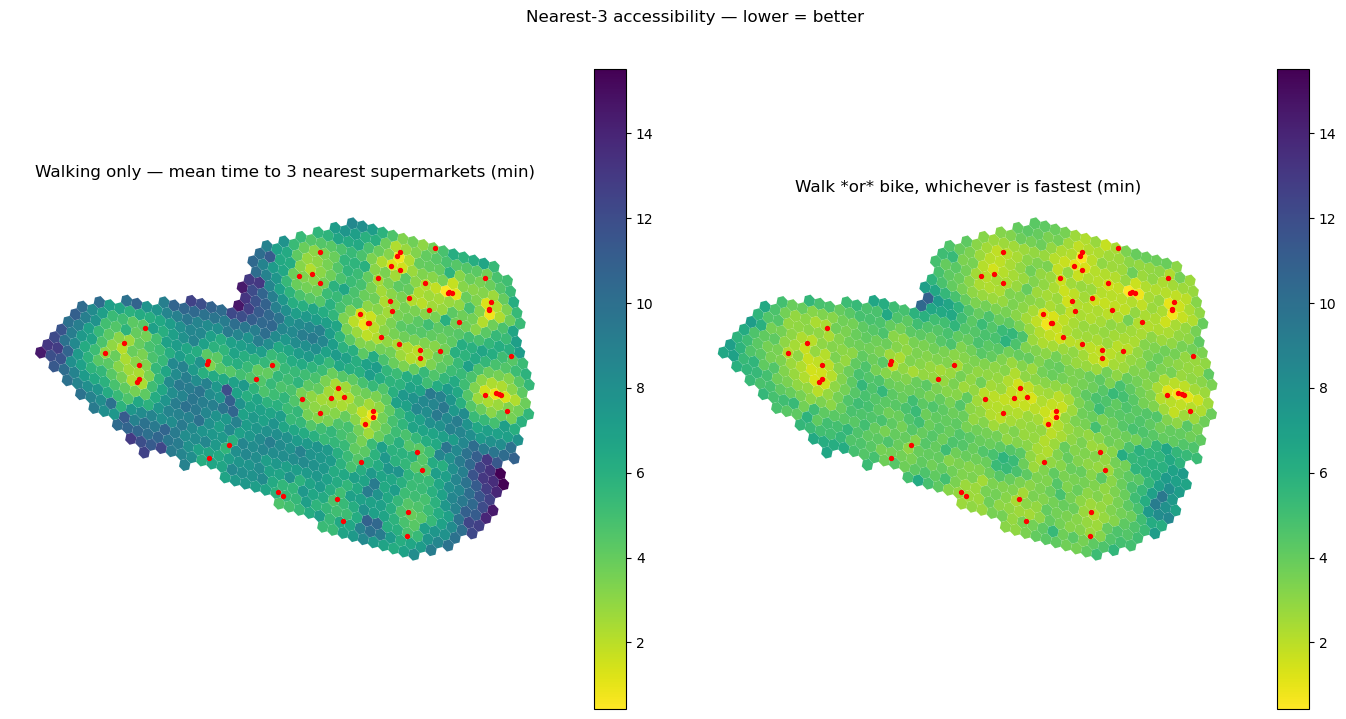

In [30]:
viz.plot_cell_values_comparison(
    cells,
    {'Walking only — mean time to 3 nearest supermarkets (min)':
         acc_nk[(3, 'supermarkets')] / 60,
     'Walk *or* bike, whichever is fastest (min)':
         acc_nk_fastest[(3, 'supermarkets')] / 60},
    suptitle='Nearest-3 accessibility — lower = better',
    cmap='viridis_r',
    overlays=[(supermarkets, {'color': 'red', 'markersize': 8})],
)
plt.show()

## 13. Utility-based accessibility & cross-modal logsum

Discrete-choice-style accessibility: define a per-mode *utility* function
combining travel cost, per-edge route features, and endpoint features,
then derive the canonical *logsum* accessibility from it. Cycling is the
more interesting case (it carries a route-feature term for bike-
friendliness from §11), so we lead with bike; walking, a simpler
cost-only spec, follows. We then combine both modes into a single
cross-modal logsum.

A linear utility per OD pair:

    U_ij = constant
         + β_cost · cost_ij                       (routing weight)
         + Σ_f β_f · aggregated_f(i, j)            (route features)
         + Σ_o β_o · feature_o(i)                  (origin features)
         + Σ_d β_d · feature_d(j)                  (destination features)

### 13.1 Bike utility with a route-feature

    U_bike = −7 − 0.7 · (t_bike / 60) + 1.0 · mean_bike_score_on_path

- **Constant −7**: Alternative-specific constant. Non-trivial setup before any trip (walk to bike,
  unlock, helmet).
- **Time coefficient −0.7 / minute**: time costs disutility, but less
  per minute than walking (−1, below). Cycling time is less unpleasant
  minute-for-minute.
- **Route-feature coefficient +1.0 on mean bike-friendliness score**:
  `edge_bike_score` from §11 (1 = busy primary, 5 = cycleway), averaged
  along the realised route. Positive coefficient = bike-friendlier
  routes raise utility.

`RouteFeature` triggers `tiered_path_aggregate` internally — one
routing pass returns both the cost and the per-OD-pair averaged bike
score along the realised path.

In [31]:
bike_utility = utility.Utility(
    constant=-7.0,
    cost_coefficient=-0.7 / 60.0,    # utils per second (= −0.7 per minute)
    route_features=[
        utility.RouteFeature(
            name='bike_score_avg',
            attribute=edge_bike_score,
            coefficient=1.0,
            aggregator='mean',
        ),
    ],
)

**Step 1**: compute the route-dependent utility components
(β_cost · cost + Σ β_route · feature). Wraps `tiered_path_aggregate`
internally so the routing pass is shared across the cost and all features.

In [32]:
bike_route_u = utility.route_utility(
    bike_pairs, bike_graph, weight='bike_time_s', utility=bike_utility,
)

**Step 2**: add the constant + origin + destination components. This
example has neither origin nor destination features in the utility (the
destination "attractiveness" enters via the supermarket weight in the
gravity step below), so this just adds the −4 constant.

In [33]:
bike_full_u = utility.add_endpoint_utility(
    bike_route_u, bike_pairs, bike_utility, cells=cells,
)

**Step 3**: lift to geo-keyed form, then bake the per-cell bike origin
overhead into the utility ODM via `add_origin_cell_overhead`. Units
already match (utils + utils) because we pre-multiply `bike_overhead_s`
by `β_cost`, so no per-call overhead-conversion is needed.

In [34]:
_, bike_full_u_geo = od_pairs.reindex_by_geo_unit(
    bike_pairs, bike_full_u, cells,
    cell_node_column='bike_node_id',
    zones=zones, zone_node_column='bike_node_id',
)
cells['bike_util_overhead'] = bike_utility.cost_coefficient * cells['bike_overhead_s']
bike_full_u_geo = overhead.add_origin_cell_overhead(
    bike_full_u_geo, bike_pairs_geo, cells, 'bike_util_overhead',
)

### 13.2 Walking utility (cost-only)

    U_walk = −3 − 1 · (t_walk / 60)

Smaller constant (−3 vs −7) reflects walking's lower setup cost; stronger
time coefficient (−1 vs −0.7 per minute) reflects that a minute of walking
is more onerous than a minute of cycling. No route feature → the pipeline
is identical to bike but skips the per-edge aggregation pass.

In [35]:
walking_utility = utility.Utility(
    constant=-3.0,
    cost_coefficient=-1.0 / 60.0,
)
route_u = utility.route_utility(
    pairs, graph, weight='walk_time_s', utility=walking_utility,
)
full_u = utility.add_endpoint_utility(route_u, pairs, walking_utility, cells=cells)
_, full_u_geo = od_pairs.reindex_by_geo_unit(
    pairs, full_u, cells,
    cell_node_column='node_id',
    zones=zones, zone_node_column='node_id',
)
cells['util_overhead'] = walking_utility.cost_coefficient * cells['walk_overhead_s']
full_u_geo = overhead.add_origin_cell_overhead(
    full_u_geo, pairs_geo, cells, 'util_overhead',
)

### 13.3 Per-mode logsum accessibility

Gravity-on-utility with the `exp` decay = expected sum of attractiveness
across destinations, weighted by `exp(utility)`. Taking the log of that
sum gives the canonical *logsum accessibility* — the discrete-choice
expected utility from the choice set.

Logsum is in the same units as utility (utils). It can be negative when
the accessible attractiveness is low — that's expected for cells far from
any supermarket or facing long travel times. *Less negative = better
access.* When no destinations are reachable, the gravity sum is 0 and
`log(0) = -inf`; viz treats these as missing.

In [36]:
# Custom decay: gravity expects `exp(-β · cost)`, but utility is "more = better"
# (not a cost). Plain `np.exp` applied to utility gives the correct exp(U).
exp_utility_decay = accessibility.Decay('exp_u', np.exp)

# Walk-only logsum.
gravity_u_walk = accessibility.gravity(
    full_u_geo, {'supermarkets': sm_weights}, cell_to_zone, exp_utility_decay,
)
walk_logsum = np.log(gravity_u_walk[('exp_u', 'supermarkets')]).rename('walk_logsum')

# Bike-only logsum. Destination weights aligned to bike_pairs_geo: same cells
# as the walk weights, but the per-origin reachable sets differ.
sm_weights_bike = od_pairs.dest_values_geo(
    'supermarkets', bike_pairs_geo, cells, zones=zones,
)
gravity_u_bike = accessibility.gravity(
    bike_full_u_geo, {'supermarkets': sm_weights_bike}, cell_to_zone,
    exp_utility_decay,
)
bike_logsum = np.log(gravity_u_bike[('exp_u', 'supermarkets')]).rename('bike_logsum')

### 13.4 Cross-modal logsum (walk + bike, utility domain)

The canonical cross-modal logsum accessibility:

    A_i = ln Σ_j W_j Σ_m exp(U_ijm)

Combine the per-mode utility ODMs into a single combined ODM via
`aggregate_across_modes` with a custom utility-domain logsum aggregator,
then apply gravity-on-utility + log.

**Note on equivalence with the per-mode shortcut.** Unlike the
cross-modal nearest-*k* in §12 (where the in-loop min was load-bearing),
the gravity-on-utility logsum is algebraically `ln(Σ_m G_im)` where
`G_im = Σ_j W_j · exp(U_ijm)` is the per-mode gravity-on-utility — i.e.
`log(exp(walk_logsum) + exp(bike_logsum))` gives the same answer (a
sum-order swap). The in-loop pattern below is here for API consistency
with §12, dest-set-union handling, and skipping an `exp → log → exp →
log` round-trip. For cumulative-opportunity or nearest-*k* cross-modal
accessibility the in-loop aggregation is the *only* mathematically
correct path.

In [37]:
def logsum_utility(stacked: np.ndarray) -> np.ndarray:
    """Cross-modal logsum in *utility* space (more = better).

    Stacked shape: `(n_modes, n_dests)`. Per OD pair, returns
    `ln Σ_m exp(U_ijm)` — the expected-max-utility across modes.
    NaN entries (mode unreachable for that OD pair) contribute 0 to the sum.
    """
    exp_terms = np.exp(stacked)
    exp_terms = np.where(np.isnan(exp_terms), 0.0, exp_terms)
    sum_exp = exp_terms.sum(axis=0)
    with np.errstate(divide='ignore'):
        return np.log(sum_exp)


combined_u_pairs, combined_u = od_pairs.aggregate_across_modes(
    {'walk': (pairs_geo, full_u_geo),
     'bike': (bike_pairs_geo, bike_full_u_geo)},
    aggregator=logsum_utility,
)

# Destination weights aligned to the UNION dest set across modes.
sm_weights_combined = od_pairs.dest_values_geo(
    'supermarkets', combined_u_pairs, cells, zones=zones,
)
gravity_combined = accessibility.gravity(
    combined_u, {'supermarkets': sm_weights_combined}, cell_to_zone,
    exp_utility_decay,
)
cross_modal_logsum = np.log(
    gravity_combined[('exp_u', 'supermarkets')]
).rename('cross_modal_logsum')

Side-by-side: walk-only, bike-only, and cross-modal walk-or-bike logsum,
on a shared colour scale. Cells where no mode reaches any supermarket
appear as missing.

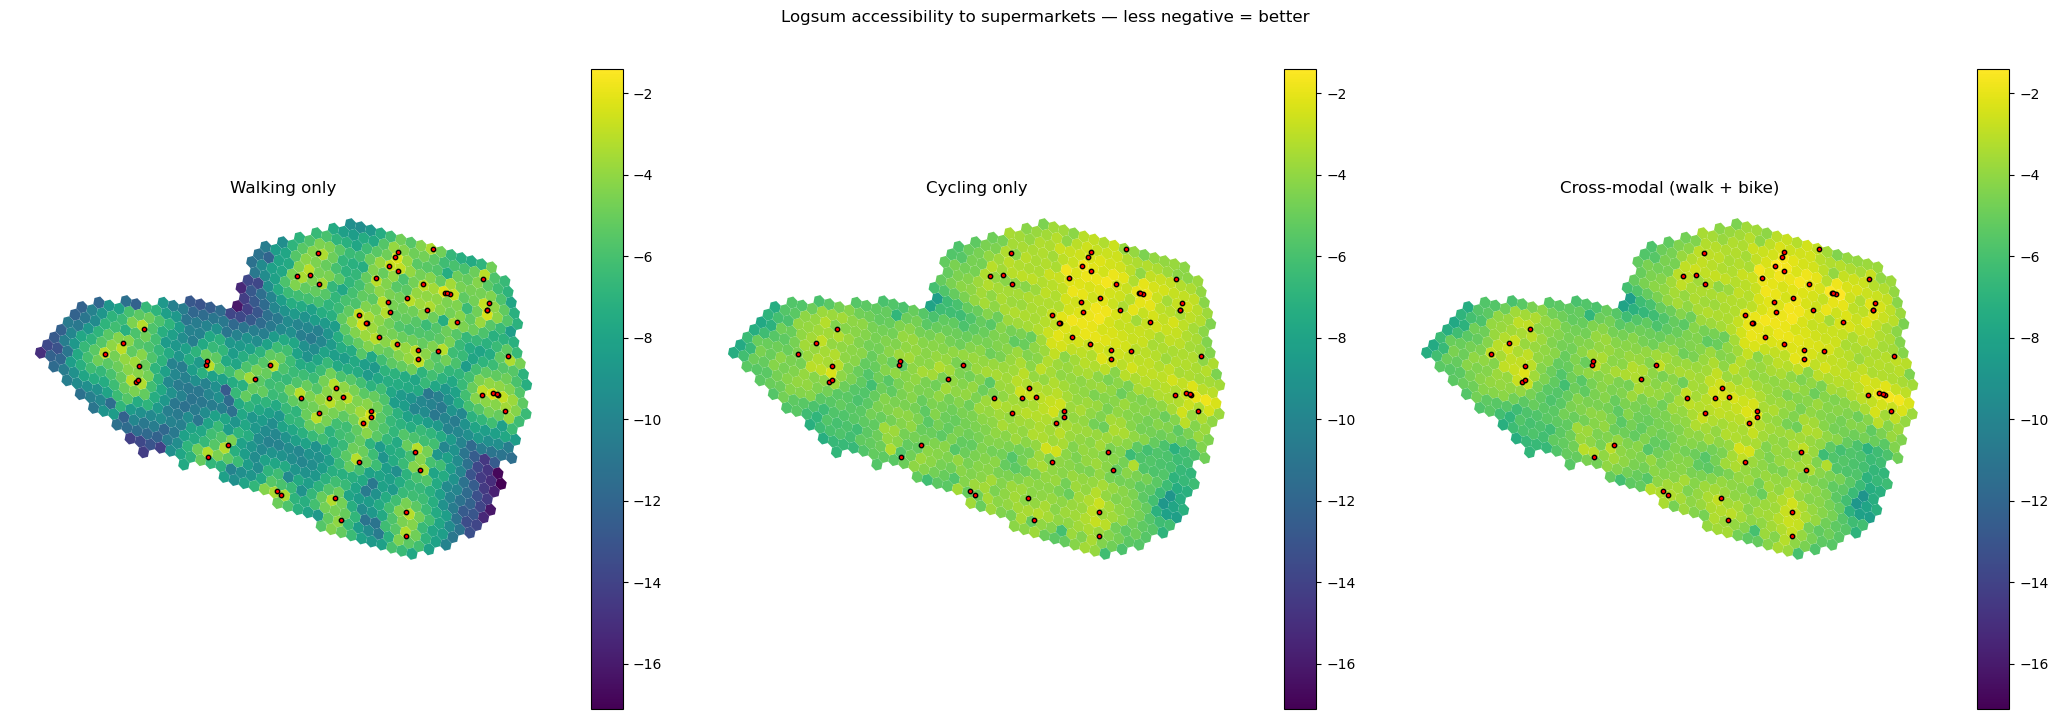

In [38]:
viz.plot_cell_values_comparison(
    cells,
    {'Walking only': walk_logsum,
     'Cycling only': bike_logsum,
     'Cross-modal (walk + bike)': cross_modal_logsum},
    suptitle='Logsum accessibility to supermarkets — less negative = better',
    overlays=[(supermarkets,
               {'color': 'red', 'markersize': 10, 'edgecolor': 'black'})],
)
plt.show()

The cross-modal map is uniformly *less negative* (better) than either
single-mode map — adding a second mode can only expand reachability. The gap
between walking-only and cross-modal is largest in cells far from any
supermarket: walking sees long travel times (very negative utility, very small
contribution to the gravity sum), but cycling brings them within practical
reach. In dense central cells with many walkable supermarkets, the walking
utility already dominates the modal sum and the cross-modal addition is small.
In addition, we see the cycling infrastructure quality (mean bike score on
routes) take effect: cycling utility, and therefore combined utility, is
strongest and most homogeneous in the northeastern part of the city, where the
mean bike-friendliness along routes was highest.

Architectural notes:

- Each mode has its own graph, its own node IDs, its own edge attributes,
  and its own snapping. Alignment happens only at the geo-unit (cell / zone)
  level via `TieredODGeoPairs`.
- Per-mode origin overhead is baked into the per-mode utility ODM
  *before* aggregation, so the cross-modal logsum sees the right
  mode-specific first-mile cost (walking at 1.4 m/s vs cycling with a
  30-second unlock setup).
- `aggregate_across_modes` unions the per-origin dest sets across modes
  and fills missing entries with `inf` (mode-unreachable). For our example,
  walk and bike cover roughly the same Central Paris cells, but at country
  scale this matters — different modes naturally reach different sub-graphs.
- Destination-side overheads (last-mile, also mode-specific) are NOT
  baked into the utility ODMs in this walkthrough. A production
  analysis would add them via `add_geo_overheads(dest_cell=...,
  dest_zone=...)` on each per-mode utility ODM before aggregation, using
  mode-specific utils-per-second conversions.